# **1DCNN модель, для задачм предсказания ECM параметров**.

## Загрузка данных

Библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

import os

Распаковка данных

In [2]:
!python -m zipfile -e /content/param_ecm-new_data_param.zip /content/

### Загрузка датасетов.

In [3]:
target_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_main.csv'

feature_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_pls_tables'

In [4]:
y_data = pd.read_csv(target_path)
y_data.head(3)

,I,R0,R1,R2,Udrop,Ufin,Uinit,cellcap,dSoC,dltQ,name,nominal_soc,tau1,tau2,tau_pls,table_file
0,-1.699624,0.035922,0.021680,0.002503,0.0576,3.6642,3.6656,3.36,-0.001265,-15.296620,soc45_05Cdch_9sec,0.45,49.006981,100,9,soc45_05Cdch_9sec.csv
1,-1.699615,0.038267,0.026703,0.004275,0.0596,3.6627,3.6653,3.36,-0.002529,-30.593065,soc45_05Cdch_18sec,0.45,71.978738,100,18,soc45_05Cdch_18sec.csv
2,-1.699670,0.039573,0.029765,0.006881,0.0597,3.6611,3.6656,3.36,-0.005059,-61.188125,soc45_05Cdch_36sec,0.45,98.442333,100,36,soc45_05Cdch_36sec.csv


In [13]:
X_data_dict = {}

for filename in os.listdir(feature_path):
  if filename.endswith('.csv'):
    full_path = os.path.join(feature_path, filename)

    X_data_dict[filename] = pd.read_csv(full_path)[['Time', 'I', 'E']]

filenames_list = list(X_data_dict.keys())

print(f"Всего файлов загружено: {len(filenames_list)}")
print(f"Первый файл: {filenames_list[0]}")

Всего файлов загружено: 72
Первый файл: soc45_1Cchr_9sec.csv


In [14]:
first_filename = filenames_list[0]
first_dataframe = X_data_dict[first_filename]

first_dataframe.head(3)

,Time,I,E
0,0.0,3.3983,3.7847
1,0.1,3.3983,3.7847
2,0.2,3.3984,3.7859


### Преобразуем данные, оставим, только что нужно.

In [12]:
y_data_valid = y_data.copy()

y_data_valid = y_data_valid[['R0', 'R1', 'R2', 'tau1', 'tau2', 'table_file']]
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2,table_file
0,0.035922,0.021680,0.002503,49.006981,100,soc45_05Cdch_9sec.csv
1,0.038267,0.026703,0.004275,71.978738,100,soc45_05Cdch_18sec.csv
2,0.039573,0.029765,0.006881,98.442333,100,soc45_05Cdch_36sec.csv


In [16]:
y_data_valid = y_data_valid.set_index('table_file')
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2
table_file,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,49.006981,100
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,71.978738,100
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,98.442333,100


Проверю доступность строк.

In [18]:
y_data_valid.loc['soc45_05Cdch_9sec.csv']

,soc45_05Cdch_9sec.csv
R0,0.035922
R1,0.021680
R2,0.002503
tau1,49.006981
tau2,100.000000


### Данные и их статистики.

Фичи

In [19]:
X_data_dict['soc45_05Cchr_144sec.csv'].describe()

,Time,I,E
count,5163.000000,5163.000000,5163.000000
mean,755.717606,0.474423,3.691385
std,1540.981196,0.762543,0.032478
min,0.000000,0.000000,3.667200
25%,129.050000,0.000000,3.669300
50%,258.000000,0.000000,3.671600
75%,387.050000,1.699800,3.726700
max,7644.000000,1.699900,3.756300


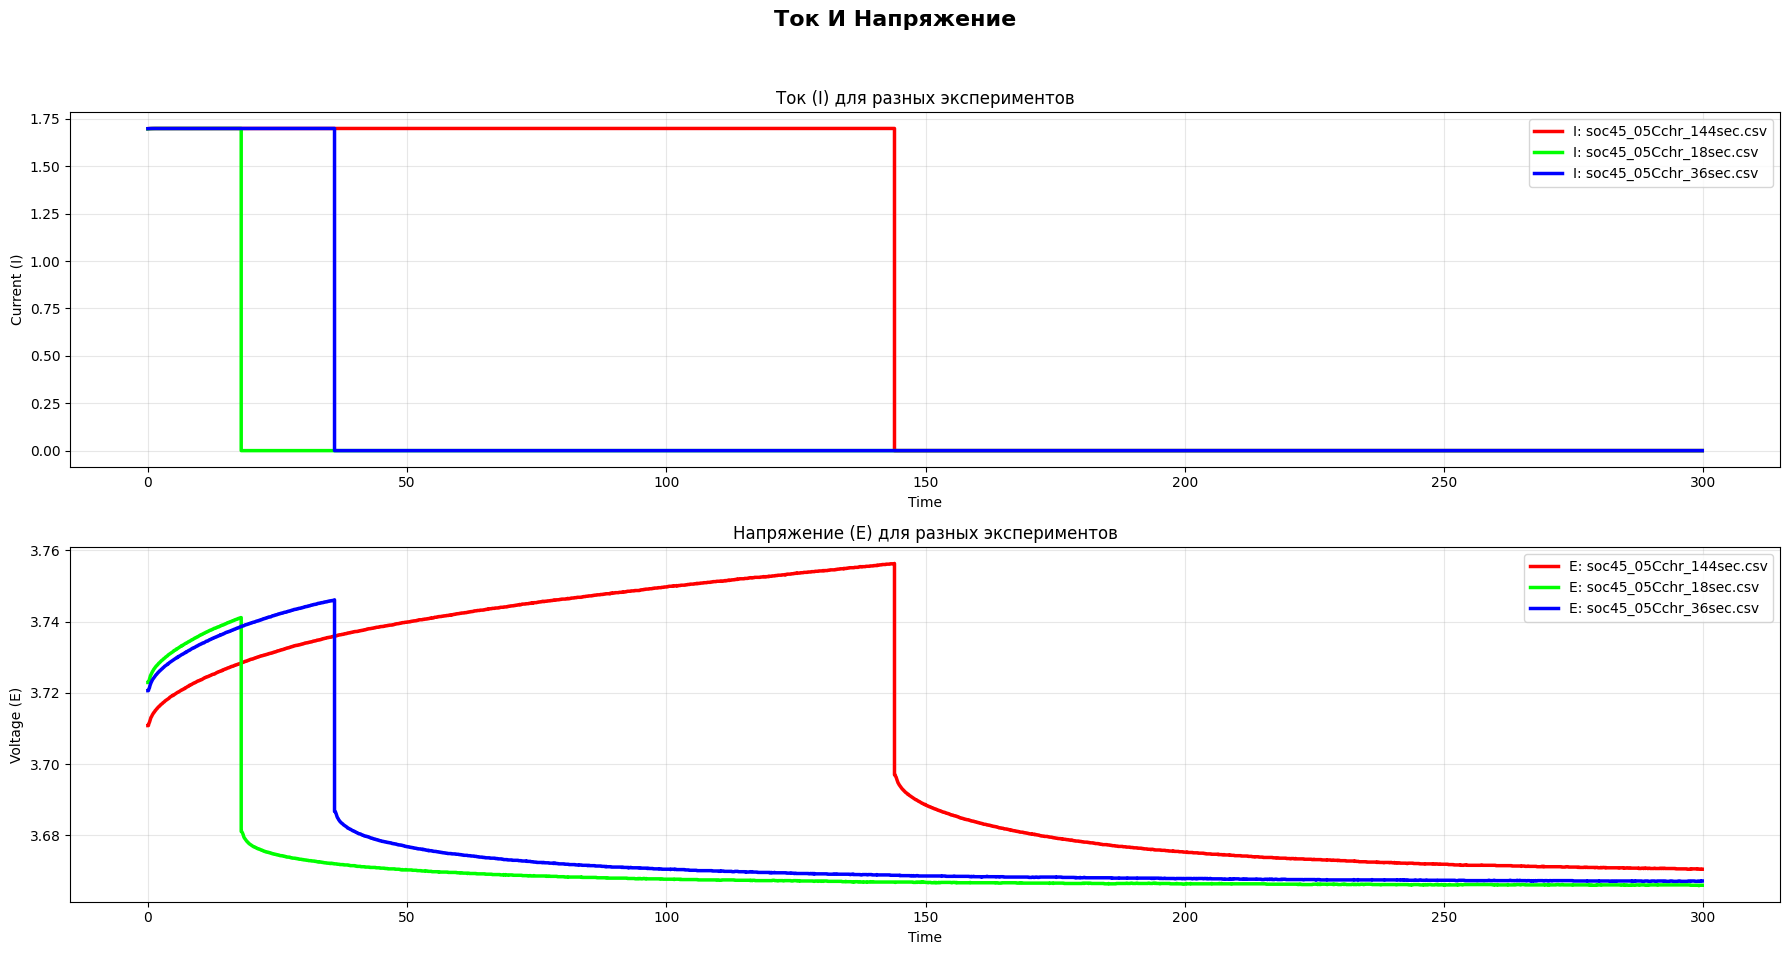

In [26]:
filenames_list = sorted([f for f in X_data_dict.keys() if f.endswith('.csv')])
files_to_plot = filenames_list[:3]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
axes = axes.flatten()

colors = ['#FF0000', '#00FF00', '#0000FF']

for i, filename in enumerate(files_to_plot):
    df = X_data_dict[filename]
    color = colors[i % len(colors)]

    df_trimmed = df.iloc[:3000]

    ax_I = axes[0]
    ax_I.plot(df_trimmed['Time'], df_trimmed['I'], color=color, linewidth=2.5, alpha=1.0, label=f'I: {filename}')
    ax_I.set_title('Ток (I) для разных экспериментов')
    ax_I.set_xlabel('Time')
    ax_I.set_ylabel('Current (I)')
    ax_I.grid(True, alpha=0.3)
    ax_I.legend(loc='upper right')

    ax_E = axes[1]
    ax_E.plot(df_trimmed['Time'], df_trimmed['E'], color=color, linewidth=2.5, alpha=1.0, label=f'E: {filename}', linestyle='-')
    ax_E.set_title('Напряжение (E) для разных экспериментов')
    ax_E.set_xlabel('Time')
    ax_E.set_ylabel('Voltage (E)')
    ax_E.grid(True, alpha=0.3)
    ax_E.legend(loc='upper right')

plt.suptitle('Ток И Напряжение', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Целевые переменные.

In [27]:
y_data_valid.describe()

,R0,R1,R2,tau1,tau2
count,72.000000,72.000000,72.000000,72.000000,72.0
mean,0.037798,0.016566,0.004256,48.864033,100.0
std,0.001375,0.004256,0.002338,18.731570,0.0
min,0.035610,0.011923,0.001788,27.611288,100.0
25%,0.036876,0.013499,0.002353,36.255334,100.0
50%,0.037680,0.015058,0.003422,43.682324,100.0
75%,0.038596,0.018286,0.005916,56.095392,100.0
max,0.041387,0.029765,0.012494,123.354520,100.0
